# EDA & Data Visualization: ปัจจัยที่เกี่ยวข้องกับ Attrition (พนักงานลาออก)

**ข้อมูล:** `employee_attrition_2026_master.csv` (45,000 แถว, 29 คอลัมน์)
**อ้างอิงรูปแบบโค้ด:** Lab 5 (`plt.bar`, `plt.pie`, `plt.plot`, `plt.hist`, `sns.barplot`, `sns.histplot`, `sns.boxplot`, `sns.regplot`)

**เป้าหมาย**
1. สำรวจข้อมูลเบื้องต้นและความสัมพันธ์กับ `attrition`
2. หา 5 กลุ่มที่ลาออกสูงสุด และ 5 กลุ่มที่อยู่ต่อมากที่สุด
3. ทำกราฟ พร้อมอธิบายโค้ดและ Insight ของแต่ละกราฟ
4. สรุปเป็น Proposal ส่วน EDA + ปัจจัยที่เกี่ยวข้องกับ Attrition

> ถ้าต้องการรันเอง: วางไฟล์ CSV ไว้โฟลเดอร์เดียวกับโค้ด โค้ดทุกก้อนต่อกันรันได้ตามลำดับ (กราฟบันทึกลงโฟลเดอร์ `figures/`)

---

## 1. Import Library และโหลดข้อมูล

In [22]:
# Import Python Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()                       # ธีม seaborn ตามที่ใช้ใน Lab 5
os.makedirs("figures", exist_ok=True) # โฟลเดอร์เก็บรูปกราฟ
print("seaborn version ", sns.__version__)

seaborn version  0.13.2


**อธิบายโค้ด**
- `numpy`, `pandas` ใช้จัดการตารางและคำนวณ
- `matplotlib.pyplot` ใช้วาดกราฟพื้นฐาน (bar, pie, line, scatter)
- `seaborn` ใช้วาดกราฟสถิติ (barplot, histplot, boxplot, regplot, heatmap)
- `sns.set_theme()` ตั้งธีมกราฟให้สวยและอ่านง่าย
- `os.makedirs(..., exist_ok=True)` สร้างโฟลเดอร์ `figures` ถ้ายังไม่มี เพื่อใช้บันทึกรูป

In [23]:
df = pd.read_csv("../data/employee_attrition_2026_master.csv")
df['attrition_pct'] = df['attrition'] * 100   # คอลัมน์ช่วย: ทำให้ค่าเฉลี่ยอ่านเป็น %
df.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition,attrition_pct
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,2,0,62,0,2,0,22,stayed,0,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,3,2,79,1,2,0,24,stayed,0,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,1,2,43,0,4,1,3,poor_management,1,100
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,1,4,64,1,3,0,24,stayed,0,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,1,1,92,0,2,0,5,stayed,0,0


**อธิบายโค้ด**
- `pd.read_csv` อ่านไฟล์ข้อมูลดิบเข้า DataFrame ชื่อ `df`
- `attrition` เป็น 0/1 ค่าเฉลี่ยของมันคือ "อัตราการลาออก" จึงสร้าง `attrition_pct` (คูณ 100) ไว้ให้แกนกราฟอ่านเป็นเปอร์เซ็นต์
- `df.head()` ดู 5 แถวแรก

---

## 2. ตรวจสอบข้อมูลเบื้องต้น

In [24]:
print("ขนาดข้อมูล (แถว, คอลัมน์):", df.shape)   # 30 คอลัมน์ = 29 เดิม + attrition_pct ที่เพิ่ม
df.info()

ขนาดข้อมูล (แถว, คอลัมน์): (45000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 45000 non-null  object 
 1   age                         45000 non-null  int64  
 2   generation                  45000 non-null  object 
 3   gender                      45000 non-null  object 
 4   department                  45000 non-null  object 
 5   job_level                   45000 non-null  object 
 6   is_manager                  45000 non-null  int64  
 7   tenure_years                45000 non-null  float64
 8   salary_usd                  45000 non-null  int64  
 9   salary_vs_market_pct        45000 non-null  float64
 10  work_arrangement            45000 non-null  object 
 11  rto_mandate                 45000 non-null  int64  
 12  days_in_office_required     45000 non-null  int64

In [25]:
# ตรวจสอบ Missing Value และข้อมูลซ้ำ
print("--- จำนวน Missing Value รวม ---", df.isnull().sum().sum())
print("employee_id ซ้ำ:", df['employee_id'].duplicated().sum())
print("แถวซ้ำทั้งแถว (ไม่นับ id):", df.drop(columns='employee_id').duplicated().sum())

--- จำนวน Missing Value รวม --- 0
employee_id ซ้ำ: 0
แถวซ้ำทั้งแถว (ไม่นับ id): 0


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45000.0,34.240711,8.547373,20.0,28.0,34.0,40.0,64.0
is_manager,45000.0,0.242044,0.428326,0.0,0.0,0.0,0.0,1.0
tenure_years,45000.0,3.598353,2.545593,0.1,1.7,3.0,4.8,25.0
salary_usd,45000.0,115385.533333,50084.707992,35000.0,75000.0,103000.0,146000.0,345000.0
salary_vs_market_pct,45000.0,-1.940573,9.990708,-35.0,-8.7,-2.0,4.8,35.0
rto_mandate,45000.0,0.422444,0.493954,0.0,0.0,0.0,1.0,1.0
days_in_office_required,45000.0,3.000022,1.578040,0.0,2.0,3.0,4.0,5.0
commute_minutes,45000.0,35.809444,25.334550,0.0,17.0,30.0,48.0,180.0
prefers_remote,45000.0,0.680800,0.466172,0.0,0.0,1.0,1.0,1.0
flexibility_importance,45000.0,2.994956,1.415595,1.0,2.0,3.0,4.0,5.0


In [27]:
# สัดส่วนตัวแปรเป้าหมาย
print(df['attrition'].value_counts())
print("อัตราการลาออกรวม: %.2f%%" % df['attrition_pct'].mean())

# ตรวจ data leakage: attrition_reason บอกคำตอบของ attrition ตรง ๆ หรือไม่
print("attrition == (reason != 'stayed') ทุกแถว:",
      (df['attrition'] == (df['attrition_reason'] != 'stayed')).all())

attrition
0    36836
1     8164
Name: count, dtype: int64
อัตราการลาออกรวม: 18.14%
attrition == (reason != 'stayed') ทุกแถว: True


**อธิบายโค้ด**
- `df.shape`, `df.info()` ดูจำนวนแถว/คอลัมน์ และชนิดข้อมูลแต่ละคอลัมน์
- `isnull().sum()` นับ Missing Value (แบบเดียวกับ Lab 5), `duplicated()` นับข้อมูลซ้ำ
- `describe().T` สรุปสถิติเชิงพรรณนา (mean, std, min, quartile, max) ของตัวแปรตัวเลข สลับแกนให้อ่านง่าย
- `value_counts()` ดูจำนวนคนที่ลาออก/อยู่ต่อ
- บรรทัดสุดท้ายเช็กว่า `attrition_reason` เป็น "เฉลยของ target" หรือไม่

**ข้อสังเกตจากข้อมูล**
- ไม่มี Missing Value, `employee_id` ไม่ซ้ำ, ไม่มีแถวซ้ำ
- ลาออก 8,164 คน (**18.14%**) อยู่ต่อ 36,836 คน (81.86%) ข้อมูลค่อนข้าง imbalance (ไม่ถึงขั้นรุนแรง)
- `attrition_reason` = `'stayed'` เมื่อ `attrition = 0` เท่านั้น ถือเป็น **data leakage** ห้ามใช้เป็นตัวทำนายถ้าจะทำโมเดล ใช้ได้เฉพาะอธิบายสาเหตุหลังเกิดการลาออก
- ค่าผิดปกติที่ควรรู้: `tenure_years` สูงสุด 25 ปี (มีเพียง 101 คนที่เกิน 15 ปี), กลุ่ม Boomer มีเพียง 103 คน, เพศ Other มี 884 คน จึงต้องระวังการตีความกลุ่มเล็ก

---

## 3. กราฟและ Insight

### กราฟที่ 1: ภาพรวมการลาออก (Pie Chart)

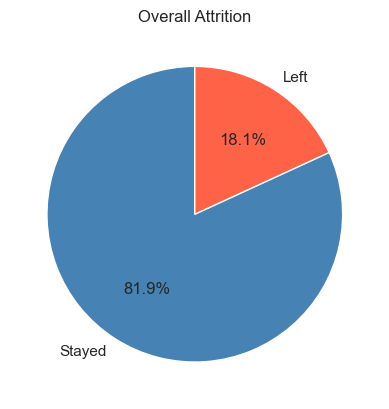

In [28]:
attr_count = df['attrition'].value_counts().sort_index()   # 0=Stayed, 1=Left

plt.pie(attr_count, labels=['Stayed', 'Left'],
        colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
plt.title('Overall Attrition')
plt.savefig("figures/01_overall_pie.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `value_counts().sort_index()` นับคนอยู่ต่อ/ลาออก และเรียงตาม 0, 1
- `plt.pie` วาดสัดส่วนส่วนต่อทั้งหมด (ตามที่ Lab 5 ใช้) `autopct` แสดงเปอร์เซ็นต์ในแต่ละชิ้น `startangle=90` เริ่มวาดจากด้านบน
- `plt.savefig` บันทึกรูป ก่อน `plt.show()`

**เหตุผลที่เลือกกราฟนี้:** Pie เหมาะกับ "สัดส่วนของทั้งหมด" ที่มีเพียง 2 กลุ่ม

**Insight**
- พนักงานลาออก **18.1%** หรือราว 1 ใน 5.5 คน ใช้เป็นเส้นฐาน (baseline) เทียบกลุ่มย่อยในกราฟถัดไป

---

### กราฟที่ 2: เหตุผลที่ลาออก (Horizontal Bar Chart)

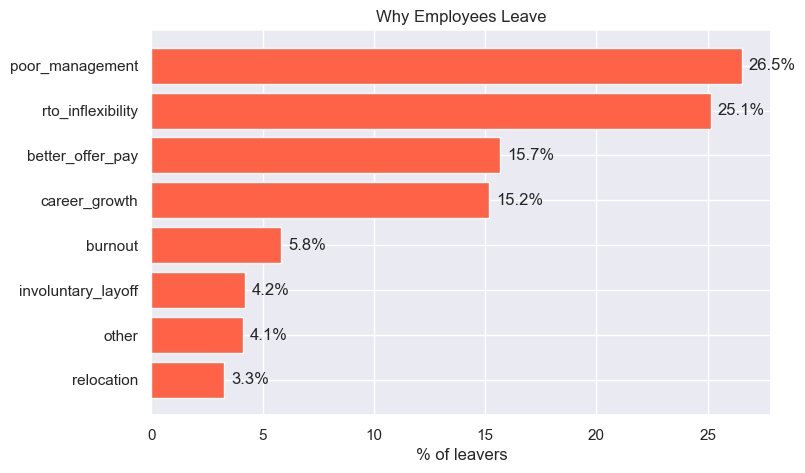

In [29]:
# เฉพาะคนที่ลาออก นับเหตุผลแล้วแปลงเป็น %
reason = df[df['attrition'] == 1].groupby('attrition_reason')['attrition'].count()
reason_pct = (reason / reason.sum() * 100).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(reason_pct.index, reason_pct.values, color='tomato')
for i, v in enumerate(reason_pct.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center')   # ใส่ตัวเลขท้ายแท่ง
plt.xlabel('% of leavers')
plt.title('Why Employees Leave')
plt.savefig("figures/02_attrition_reason.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- กรอง `attrition == 1` แล้ว `groupby('attrition_reason').count()` เหมือนที่ Lab 5 ใช้ `groupby(['rank'])['salary'].count()`
- หารด้วยผลรวมเพื่อเป็นเปอร์เซ็นต์ และ `sort_values()` ให้แท่งยาวสุดอยู่บน
- `plt.barh` เป็น bar แนวนอน เหมาะเมื่อชื่อหมวดยาว
- `plt.text` เขียนตัวเลขกำกับท้ายแท่ง

**เหตุผลที่เลือกกราฟนี้:** Bar แนวนอนเปรียบเทียบหมวดหมู่ได้ชัดและอ่านชื่อหมวดง่าย

**Insight**
- เหตุผลอันดับ 1 คือ **Poor management 26.5%** และอันดับ 2 **RTO inflexibility 25.1%** รวมกันกว่า **51.6%** ของคนที่ลาออกทั้งหมด
- ตามมาด้วยค่าตอบแทนที่ดีกว่า (15.7%) และการเติบโตในสายงาน (15.2%)
- Burnout (5.8%), ถูกเลิกจ้าง (4.2%), อื่น ๆ (4.1%), ย้ายที่อยู่ (3.3%) เป็นสาเหตุรอง
- สาเหตุหลัก 4 อันดับแรก (~82%) ล้วนเป็นสิ่งที่องค์กร "จัดการได้" ไม่ใช่ปัจจัยภายนอก

---

### กราฟที่ 3: 5 กลุ่มที่ลาออกสูงสุด vs 5 กลุ่มที่อยู่ต่อมากที่สุด

> กลุ่ม (segment) = **แผนก × รูปแบบการทำงาน** (department × work_arrangement) รวม 27 กลุ่ม แต่ละกลุ่มมีพนักงานอย่างน้อย 718 คน
> เลือกการแบ่งนี้เพราะแผนกเดียวแทบไม่ต่างกัน (ดูกราฟที่ 4) แต่รูปแบบการทำงานต่างกันมาก

In [30]:
# สร้างตารางอัตราลาออกของแต่ละกลุ่ม
seg = df.groupby(['department', 'work_arrangement'])['attrition_pct'].agg(['mean', 'count']).reset_index()
seg['segment'] = seg['department'] + ' / ' + seg['work_arrangement']
seg['attrition_rate'] = seg['mean']
seg['retention_rate'] = 100 - seg['attrition_rate']

top5_attr = seg.nlargest(5, 'attrition_rate')    # ลาออกสูงสุด 5 อันดับ
top5_ret = seg.nlargest(5, 'retention_rate')     # อยู่ต่อมากสุด 5 อันดับ

print(top5_attr[['segment', 'count', 'attrition_rate']].round(2).to_string(index=False))
print(top5_ret[['segment', 'count', 'retention_rate']].round(2).to_string(index=False))

                  segment  count  attrition_rate
     Engineering / onsite   2844           34.77
Customer Support / onsite   1224           34.40
       Marketing / onsite   1043           33.46
         Product / onsite   1245           33.25
              HR / onsite    760           32.63
                  segment  count  retention_rate
         Finance / remote    752           90.82
Customer Support / remote   1267           89.90
     Engineering / remote   2936           89.07
      Operations / remote   1493           88.88
       Marketing / remote   1141           88.52


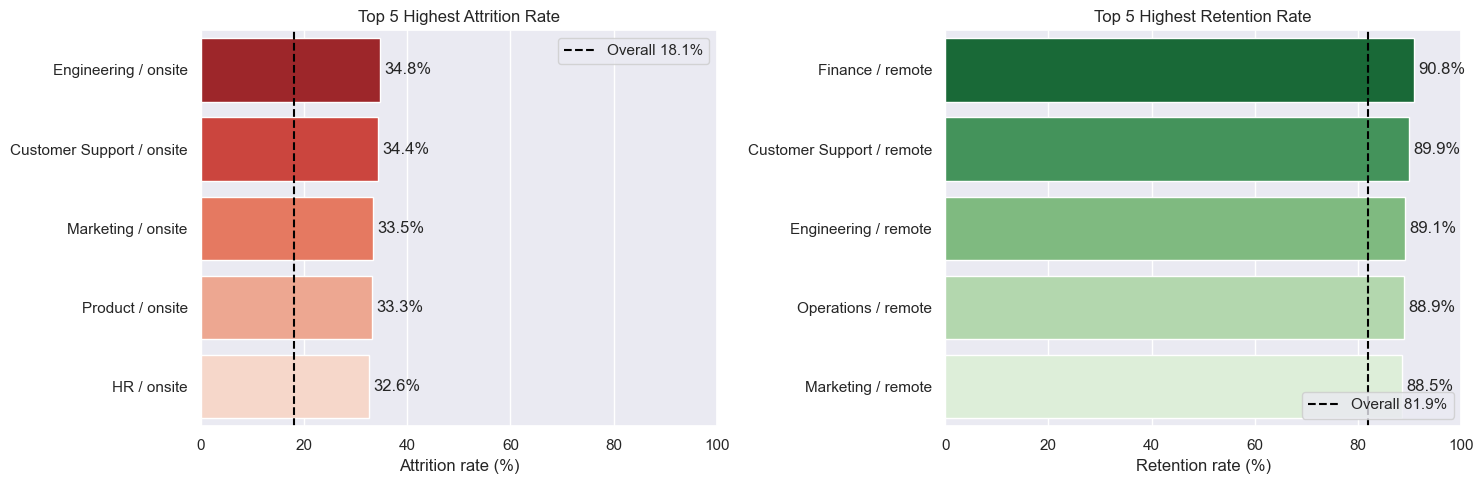

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top5_attr, x='attrition_rate', y='segment', hue='segment',
            palette='Reds_r', legend=False, ax=axes[0])
axes[0].set_title('Top 5 Highest Attrition Rate')
axes[0].set_xlabel('Attrition rate (%)')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 100)
axes[0].axvline(df['attrition_pct'].mean(), color='black', linestyle='--', label='Overall 18.1%')
axes[0].legend()
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', padding=3)

sns.barplot(data=top5_ret, x='retention_rate', y='segment', hue='segment',
            palette='Greens_r', legend=False, ax=axes[1])
axes[1].set_title('Top 5 Highest Retention Rate')
axes[1].set_xlabel('Retention rate (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].axvline(100 - df['attrition_pct'].mean(), color='black', linestyle='--', label='Overall 81.9%')
axes[1].legend(loc='lower right')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig("figures/03_top5_attrition_retention.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `groupby([...])['attrition_pct'].agg(['mean','count'])` หาอัตราลาออกและจำนวนคนต่อกลุ่มในคำสั่งเดียว
- `retention_rate = 100 - attrition_rate` อัตราอยู่ต่อ = ส่วนที่เหลือของอัตราลาออก
- `nlargest(5, ...)` ดึง 5 แถวที่ค่ามากที่สุด (ใช้ทั้งฝั่งลาออกและฝั่งอยู่ต่อ)
- `plt.subplots(1, 2)` วาด 2 กราฟคู่กัน, `sns.barplot(..., ax=...)` วาดลงช่องที่กำหนด
- `axvline` เส้นประแนวตั้งแสดงค่าเฉลี่ยรวม ไว้เทียบ, `bar_label` ใส่ตัวเลขบนแท่ง
- `set_xlim(0, 100)` ให้ทั้งสองกราฟใช้สเกลเดียวกัน ไม่หลอกตา

**เหตุผลที่เลือกกราฟนี้:** Bar chart เปรียบเทียบ "ค่าของแต่ละกลุ่ม" และจัดอันดับได้ตรงที่สุด

**ผลลัพธ์**

| อันดับ | ลาออกสูงสุด | อัตรา | อยู่ต่อมากสุด | อัตรา |
|---|---|---|---|---|
| 1 | Engineering / onsite | 34.8% | Finance / remote | 90.8% |
| 2 | Customer Support / onsite | 34.4% | Customer Support / remote | 89.9% |
| 3 | Marketing / onsite | 33.5% | Engineering / remote | 89.1% |
| 4 | Product / onsite | 33.3% | Operations / remote | 88.9% |
| 5 | HR / onsite | 32.6% | Marketing / remote | 88.5% |

**Insight**
- ทั้ง 5 กลุ่มที่ลาออกสูงสุดเป็น **onsite** ทั้งหมด และทั้ง 5 กลุ่มที่อยู่ต่อมากที่สุดเป็น **remote** ทั้งหมด
- คนที่ทำงาน onsite ลาออกราว **1.8 เท่า** ของค่าเฉลี่ยองค์กร (~33% vs 18%)
- สรุปได้ว่า "รูปแบบการทำงาน" สำคัญกว่า "แผนก" มาก
- Engineering onsite ขนาดกลุ่มใหญ่ (2,844 คน) จึงเป็นกลุ่มที่กระทบองค์กรมากสุด

---

### กราฟที่ 4: อัตราลาออกรายแผนก (Bar Chart)

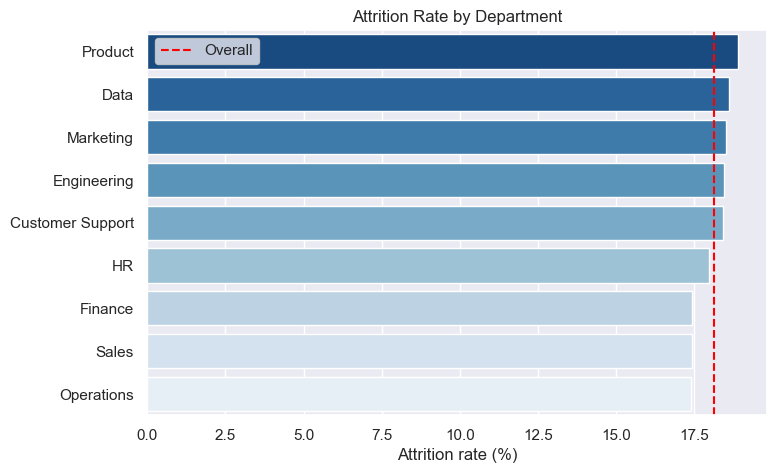

In [32]:
dept = df.groupby('department')['attrition_pct'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=dept.values, y=dept.index, hue=dept.index, palette='Blues_r', legend=False)
plt.axvline(df['attrition_pct'].mean(), color='red', linestyle='--', label='Overall')
plt.xlabel('Attrition rate (%)')
plt.ylabel('')
plt.title('Attrition Rate by Department')
plt.legend()
plt.savefig("figures/04_attrition_by_department.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `groupby('department')['attrition_pct'].mean()` อัตราลาออกต่อแผนก (ใช้หลักเดียวกับ `df.groupby(['rank'])['salary'].mean()` ใน Lab 5)
- `sns.barplot` วาดแท่งแนวนอน, `axvline` เส้นค่าเฉลี่ยองค์กร

**Insight**
- ทุกแผนกอยู่ในช่วงแคบมาก **17.4% – 18.9%** (สูงสุด Product 18.9%, ต่ำสุด Operations/Sales 17.4%)
- แผนกไม่ใช่ตัวแยกความเสี่ยงที่ดี ปัจจัยที่ทำให้ต่างกันจริงคือเรื่องรูปแบบการทำงาน ผู้จัดการ และความผูกพัน (ดูกราฟถัดไป)

---

### กราฟที่ 5: ลักษณะประชากรและการใช้ AI (Bar Chart 2x2)

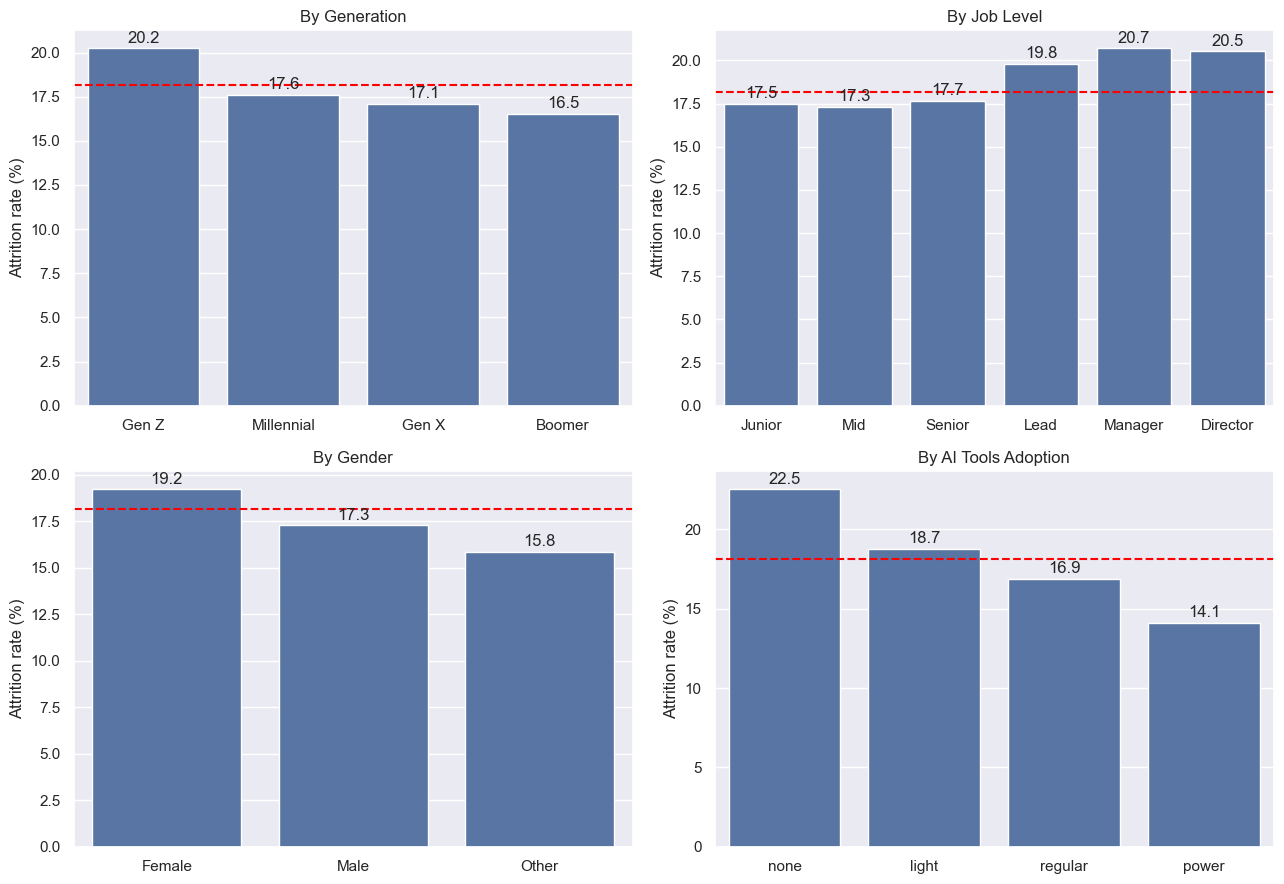

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.barplot(x='generation', y='attrition_pct', data=df, errorbar=None, ax=axes[0, 0],
            order=['Gen Z', 'Millennial', 'Gen X', 'Boomer'])
axes[0, 0].set_title('By Generation')

sns.barplot(x='job_level', y='attrition_pct', data=df, errorbar=None, ax=axes[0, 1],
            order=['Junior', 'Mid', 'Senior', 'Lead', 'Manager', 'Director'])
axes[0, 1].set_title('By Job Level')

sns.barplot(x='gender', y='attrition_pct', data=df, errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title('By Gender')

sns.barplot(x='ai_tools_adoption', y='attrition_pct', data=df, errorbar=None, ax=axes[1, 1],
            order=['none', 'light', 'regular', 'power'])
axes[1, 1].set_title('By AI Tools Adoption')

for ax in axes.flat:
    ax.axhline(df['attrition_pct'].mean(), color='red', linestyle='--')  # เส้นค่าเฉลี่ยรวม
    ax.set_ylabel('Attrition rate (%)')
    ax.set_xlabel('')
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f', padding=2)

plt.tight_layout()
plt.savefig("figures/05_demographics_ai.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `sns.barplot(x=..., y='attrition_pct', errorbar=None)` ค่าเฉลี่ยของ `attrition_pct` ในแต่ละหมวด = อัตราลาออก (Lab 5 ใช้รูปแบบ `sns.barplot(x='rank', y='salary', ...)`)
- `order=[...]` กำหนดลำดับหมวดให้เป็นธรรมชาติ (เช่น Junior → Director)
- `plt.subplots(2, 2)` สร้าง 4 กราฟในรูปเดียว, `axes.flat` วนใส่เส้นค่าเฉลี่ยและตัวเลขให้ทุกกราฟ

**Insight**
- **Generation:** Gen Z ลาออกสูงสุด 20.2% เทียบกับ Millennial 17.6%, Gen X 17.1% (Boomer 16.5% แต่มีเพียง 103 คน ไม่ควรสรุป)
- **Job level:** ระดับ Manager (20.7%), Director (20.5%), Lead (19.8%) ลาออกมากกว่า Junior/Mid/Senior (17.3–17.7%)
- **Gender:** หญิง 19.2% สูงกว่าชาย 17.3% เล็กน้อย
- **AI tools:** ยิ่งใช้ AI มากยิ่งลาออกน้อย: none 22.5% → light 18.8% → regular 16.9% → power 14.1% (อาจเป็นความสัมพันธ์เชิงสะท้อนความผูกพัน/ความพร้อมกับองค์กร ไม่ได้แปลว่า AI เป็นสาเหตุโดยตรง)
- ความต่างของปัจจัยกลุ่มนี้อยู่ที่ราว 2–8 จุดเปอร์เซ็นต์ ซึ่งเล็กกว่ากลุ่มปัจจัยด้านการทำงานและผู้จัดการมาก

---

### กราฟที่ 6: รูปแบบการทำงาน × นโยบาย RTO (Grouped Bar Chart)

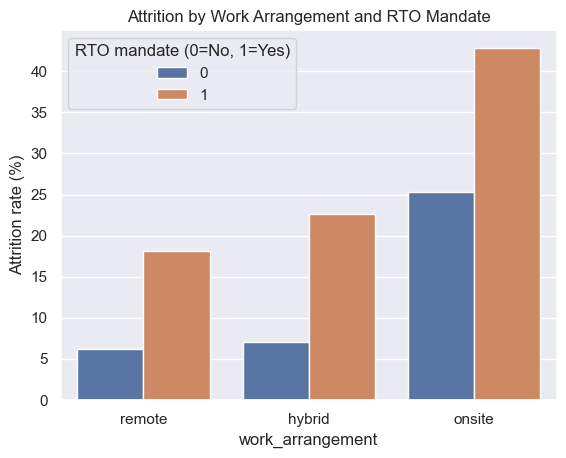

In [34]:
sns.barplot(x='work_arrangement', y='attrition_pct', hue='rto_mandate', data=df,
            order=['remote', 'hybrid', 'onsite'], errorbar=None, estimator=np.mean)
plt.ylabel('Attrition rate (%)')
plt.title('Attrition by Work Arrangement and RTO Mandate')
plt.legend(title='RTO mandate (0=No, 1=Yes)')
plt.savefig("figures/06_arrangement_rto.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- ใช้ `sns.barplot(..., hue='rto_mandate', estimator=np.mean)` แบบเดียวกับตัวอย่าง `hue='sex'` ใน Lab 5 เพื่อแยกกลุ่มย่อยภายในแต่ละหมวดและเทียบกันด้วยค่าเฉลี่ย
- `order` เรียงจาก remote → hybrid → onsite ตามระดับความเข้มของการเข้าออฟฟิศ

**Insight**
- onsite ลาออก **32.8%** สูงกว่า hybrid (13.7%) และ remote (11.2%) ถึง ~2.4–2.9 เท่า
- คนที่ถูกบังคับ RTO ลาออก **26.9%** ส่วนที่ไม่ถูกบังคับ **11.7%**
- ผลกระทบของ RTO "ซ้อนทับ" กับรูปแบบการทำงาน: onsite + RTO สูงถึง **42.8%** เทียบกับ remote ไม่มี RTO เพียง **6.2%**
- ข้อสังเกตข้อมูล: มีพนักงาน remote ที่มี `rto_mandate = 1` (5,210 คน) ลาออก 18.2% ควรตรวจสอบนิยามคอลัมน์กับเจ้าของข้อมูล

---

### กราฟที่ 7: จำนวนวันที่ต้องเข้าออฟฟิศ (Line Chart)

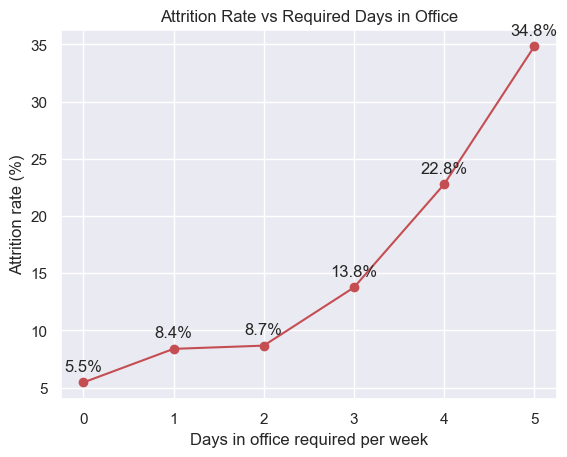

In [35]:
days = df.groupby('days_in_office_required')['attrition_pct'].mean()

plt.plot(days.index, days.values, "ro-")        # สีแดง จุดวงกลม เส้นทึบ (format string ตาม Lab 5)
for x, y in zip(days.index, days.values):
    plt.text(x, y + 1, f"{y:.1f}%", ha='center')
plt.title('Attrition Rate vs Required Days in Office')
plt.xlabel('Days in office required per week')
plt.ylabel('Attrition rate (%)')
plt.savefig("figures/07_days_in_office.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `groupby('days_in_office_required').mean()` หาอัตราลาออกตามจำนวนวันที่ต้องเข้า (0–5 วัน)
- `plt.plot(x, y, "ro-")` ใช้ format string แบบ Lab 5 (`"bo-"`): r=แดง, o=จุดวงกลม, -=เส้นทึบ
- ใช้ **Line chart** เพราะแกน x เป็นลำดับต่อเนื่อง ต้องการดูแนวโน้ม

**Insight**
- อัตราลาออกเพิ่มแบบ **ทวีความชัน**: 0 วัน 5.5% → 1 วัน 8.4% → 2 วัน 8.7% → 3 วัน 13.8% → 4 วัน 22.8% → **5 วัน 34.8%**
- ถึง 2 วัน/สัปดาห์ยังเพิ่มช้า แต่ตั้งแต่ **3 วันขึ้นไป** เริ่มกระโดด และ 4–5 วันคือโซนอันตราย
- เป็นตัวแปรที่สัมพันธ์กับ attrition สูงสุดในชุดข้อมูล (correlation = +0.26)

---

### กราฟที่ 8: ผู้จัดการ, การเติบโต, 1-on-1 (Bar Chart 1x3)

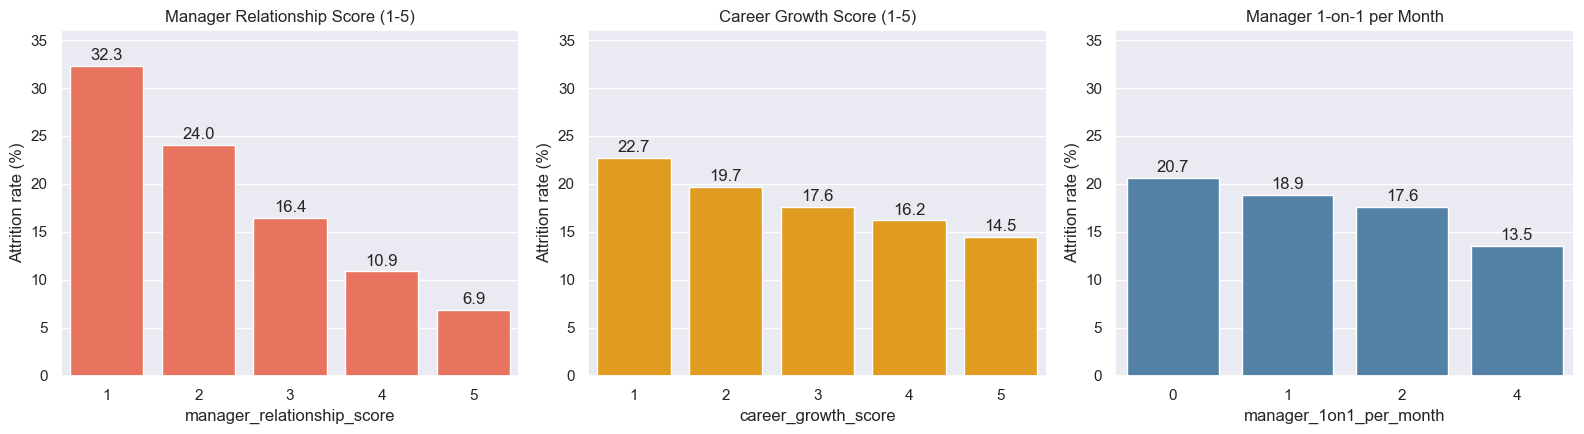

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(x='manager_relationship_score', y='attrition_pct', data=df, errorbar=None,
            color='tomato', ax=axes[0])
axes[0].set_title('Manager Relationship Score (1-5)')

sns.barplot(x='career_growth_score', y='attrition_pct', data=df, errorbar=None,
            color='orange', ax=axes[1])
axes[1].set_title('Career Growth Score (1-5)')

sns.barplot(x='manager_1on1_per_month', y='attrition_pct', data=df, errorbar=None,
            color='steelblue', ax=axes[2])
axes[2].set_title('Manager 1-on-1 per Month')

for ax in axes:
    ax.set_ylabel('Attrition rate (%)')
    ax.set_ylim(0, 36)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f', padding=2)

plt.tight_layout()
plt.savefig("figures/08_manager_growth_1on1.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- ตัวแปรทั้ง 3 เป็นคะแนน/จำนวนครั้งแบบแยกระดับ (ordinal) จึงใช้ `barplot` เทียบอัตราลาออกต่อระดับ
- `color=` ใช้สีเดียวต่อกราฟ (แบบ Lab 5) เพราะแกน x ไม่ต้องแยกสีต่อแท่ง
- `set_ylim(0, 36)` ใช้สเกลเดียวกันทั้ง 3 กราฟเพื่อเทียบความชันได้ตรง ๆ

**Insight**
- **ความสัมพันธ์กับผู้จัดการ** แรงที่สุดในกลุ่มนี้: คะแนน 1 ลาออก **32.3%** → คะแนน 5 เหลือ **6.9%** (ต่างกัน ~4.7 เท่า)
- **การเติบโตในสายงาน:** คะแนน 1 ลาออก 22.7% → คะแนน 5 เหลือ 14.5%
- **1-on-1:** ไม่เคยมี 1-on-1 ลาออก 20.7% → 4 ครั้ง/เดือน 13.5% การคุยบ่อยช่วยลดความเสี่ยงได้
- สอดคล้องกราฟที่ 2 ที่ Poor management เป็นเหตุผลอันดับ 1

---

### กราฟที่ 9: การกระจายตัวของ Engagement Score (Histogram)

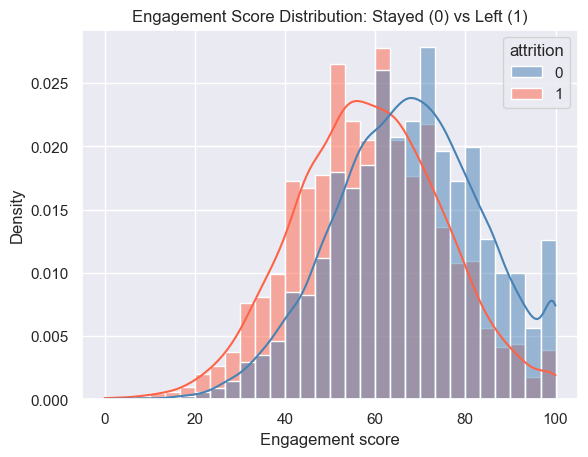

In [37]:
sns.histplot(data=df, x='engagement_score', hue='attrition', bins=30, kde=True,
             stat='density', common_norm=False, palette={0: 'steelblue', 1: 'tomato'})
plt.title('Engagement Score Distribution: Stayed (0) vs Left (1)')
plt.xlabel('Engagement score')
plt.savefig("figures/09_engagement_hist.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `sns.histplot(..., kde=True)` เหมือน Lab 5 (วาด histogram พร้อมเส้น density)
- `hue='attrition'` แยกสองกลุ่มเป็นสีต่างกันในกราฟเดียว
- `stat='density'` และ `common_norm=False` ปรับให้แต่ละกลุ่ม "รวมพื้นที่ = 1" เพื่อเปรียบเทียบรูปร่างได้ แม้จำนวนคนต่างกันมาก (36,836 vs 8,164)

**เหตุผลที่เลือกกราฟนี้:** Histogram ใช้ดู "การกระจาย" ของตัวแปรต่อเนื่อง

**Insight**
- กลุ่มที่ลาออกมี engagement **เฉลี่ย 58.6** ต่ำกว่ากลุ่มที่อยู่ต่อ **67.3** (ประมาณ 9 คะแนน)
- การกระจายของคนลาออกเลื่อนไปทางซ้าย (คะแนนต่ำ) ชัดเจน
- แบ่งตามช่วงคะแนน: ≤40 ลาออก **35.4%** แต่ >85 เหลือเพียง **7.7%**
- Engagement ต่ำ เป็นสัญญาณเตือนล่วงหน้าที่ใช้ได้จริง (correlation = −0.20)

---

### กราฟที่ 10: เปรียบเทียบการกระจายแบบ Box Plot

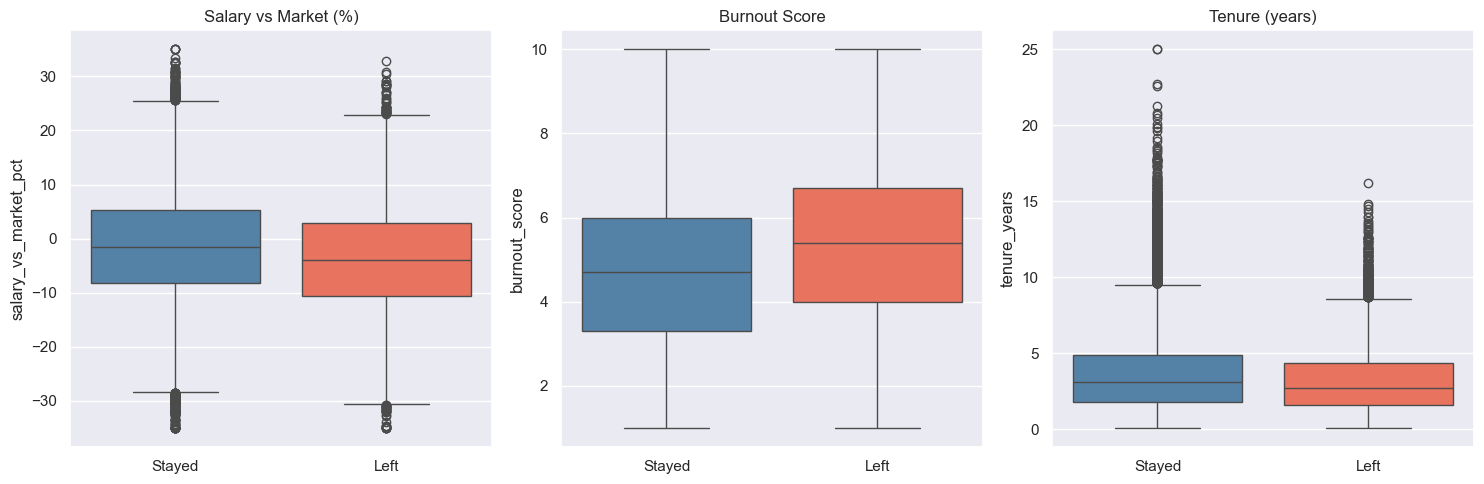

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='attrition', y='salary_vs_market_pct', data=df, hue='attrition',
            palette={0: 'steelblue', 1: 'tomato'}, legend=False, ax=axes[0])
axes[0].set_title('Salary vs Market (%)')

sns.boxplot(x='attrition', y='burnout_score', data=df, hue='attrition',
            palette={0: 'steelblue', 1: 'tomato'}, legend=False, ax=axes[1])
axes[1].set_title('Burnout Score')

sns.boxplot(x='attrition', y='tenure_years', data=df, hue='attrition',
            palette={0: 'steelblue', 1: 'tomato'}, legend=False, ax=axes[2])
axes[2].set_title('Tenure (years)')

for ax in axes:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Stayed', 'Left'])
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig("figures/10_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `sns.boxplot(x='attrition', y=..., data=df)` ตามรูปแบบ `sns.boxplot(x='rank', y='salary', data=df)` ใน Lab 5
- กล่องคือช่วง Q1–Q3, เส้นกลางคือค่ามัธยฐาน, จุดนอกหนวดคือ outlier
- ใช้ box plot เพราะต้องเทียบ "ค่ากลางและการกระจาย" ของตัวแปรต่อเนื่องระหว่าง 2 กลุ่ม

**Insight**
- **Salary vs Market:** มัธยฐานคนลาออก **−4.0%** ต่ำกว่าตลาด ส่วนคนอยู่ต่อ **−1.5%**
- **Burnout:** คนลาออกเฉลี่ย **5.37** สูงกว่าคนอยู่ต่อ **4.70**
- **Tenure:** มัธยฐานคนลาออก **2.7 ปี** น้อยกว่าคนอยู่ต่อ **3.1 ปี** คนใหม่ลาออกง่ายกว่า
- `tenure_years` มี outlier ด้านสูงชัดเจน (ถึง 25 ปี) ควรพิจารณาในขั้นโมเดล
- ความต่างของแต่ละตัวแปร "เล็กแต่สม่ำเสมอ" และกล่องของสองกลุ่มซ้อนทับกันมาก แปลว่าไม่มีตัวแปรเดี่ยวที่แยกได้เด็ดขาด ต้องดูร่วมกันหลายปัจจัย

---

### กราฟที่ 11: อัตราลาออกตามช่วงค่า (Line Chart 1x3)

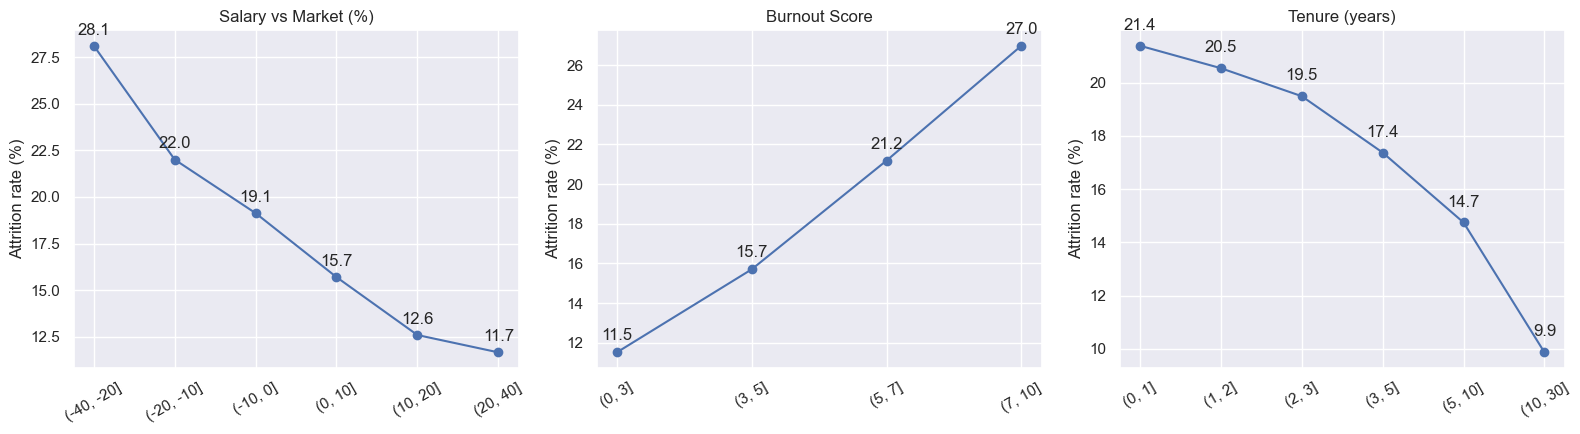

In [39]:
# แบ่งตัวแปรต่อเนื่องเป็นช่วง (bin) แล้วคำนวณอัตราลาออกในแต่ละช่วง
sal_bin = pd.cut(df['salary_vs_market_pct'], [-40, -20, -10, 0, 10, 20, 40])
bur_bin = pd.cut(df['burnout_score'], [0, 3, 5, 7, 10])
ten_bin = pd.cut(df['tenure_years'], [0, 1, 2, 3, 5, 10, 30])

sal_rate = df.groupby(sal_bin, observed=True)['attrition_pct'].mean()
bur_rate = df.groupby(bur_bin, observed=True)['attrition_pct'].mean()
ten_rate = df.groupby(ten_bin, observed=True)['attrition_pct'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, rate, title in zip(axes,
                           [sal_rate, bur_rate, ten_rate],
                           ['Salary vs Market (%)', 'Burnout Score', 'Tenure (years)']):
    ax.plot(range(len(rate)), rate.values, "bo-")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([str(i) for i in rate.index], rotation=30)
    ax.set_title(title)
    ax.set_ylabel('Attrition rate (%)')
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.6, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.savefig("figures/11_binned_rates.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `pd.cut` แบ่งตัวแปรต่อเนื่องเป็นช่วง เพื่อเปลี่ยนจาก "จุดกระจัดกระจาย" เป็น "อัตราต่อช่วง"
- `groupby(bin).mean()` อัตราลาออกต่อช่วง (`observed=True` ใช้เฉพาะช่วงที่มีข้อมูล)
- ใช้ลูป `zip` วาด 3 กราฟด้วยโค้ดชุดเดียว, `plt.plot(..., "bo-")` เส้นสีน้ำเงินแบบ Lab 5

**Insight**
- **เงินเดือนเทียบตลาด:** ต่ำกว่าตลาดเกิน 20% ลาออก **28.1%** → สูงกว่าตลาด 20% ขึ้นไป **11.7%** ลดลงต่อเนื่องทุกช่วง
- **Burnout:** ≤3 ลาออก 11.5% → >7 ลาออก **27.0%** (เพิ่มกว่า 2 เท่า)
- **อายุงาน:** ≤1 ปี 21.4% → >10 ปี **9.9%** ช่วง 3 ปีแรกเสี่ยงสูงสุด
- ทุกกราฟมีทิศทางชัด (monotonic) ทำให้ตั้งเกณฑ์เตือนได้ เช่น Burnout > 7 หรือเงินเดือนต่ำกว่าตลาดเกิน 10%

---

### กราฟที่ 12: Burnout vs ชั่วโมงทำงาน (Scatter + Regression)

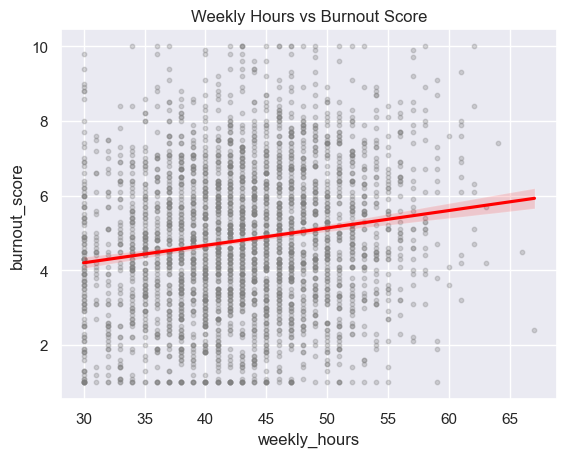

In [40]:
sample = df.sample(3000, random_state=42)   # สุ่ม 3,000 จุด ไม่ให้จุดแน่นเกินไป

sns.regplot(x='weekly_hours', y='burnout_score', data=sample,
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'gray'},
            line_kws={'color': 'red'})
plt.title('Weekly Hours vs Burnout Score')
plt.savefig("figures/12_hours_burnout.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `df.sample(3000, random_state=42)` สุ่มตัวอย่างแบบทำซ้ำได้ (ข้อมูล 45,000 จุดจะทับกันจนมองไม่เห็น)
- `sns.regplot` วาด scatter พร้อมเส้นถดถอยเชิงเส้น ตามที่ Lab 5 ใช้กับ `service` vs `salary`
- `scatter_kws`, `line_kws` ปรับความโปร่งใส/ขนาดจุด/สีเส้น

**Insight**
- ชั่วโมงทำงานสูงขึ้น Burnout สูงขึ้น (correlation = +0.17) ความสัมพันธ์ **อ่อนแต่เป็นบวก**
- จุดกระจายกว้างมาก แปลว่า Burnout ไม่ได้มาจากชั่วโมงงานอย่างเดียว
- Burnout เป็นปัจจัยทางอ้อม: ชั่วโมงงาน → Burnout → ลาออก ดังนั้นการคุมโหลดงานช่วยลดความเสี่ยงได้ในทางอ้อม

---

### กราฟที่ 13: ความสัมพันธ์ของแต่ละตัวแปรกับ Attrition (Bar Chart)

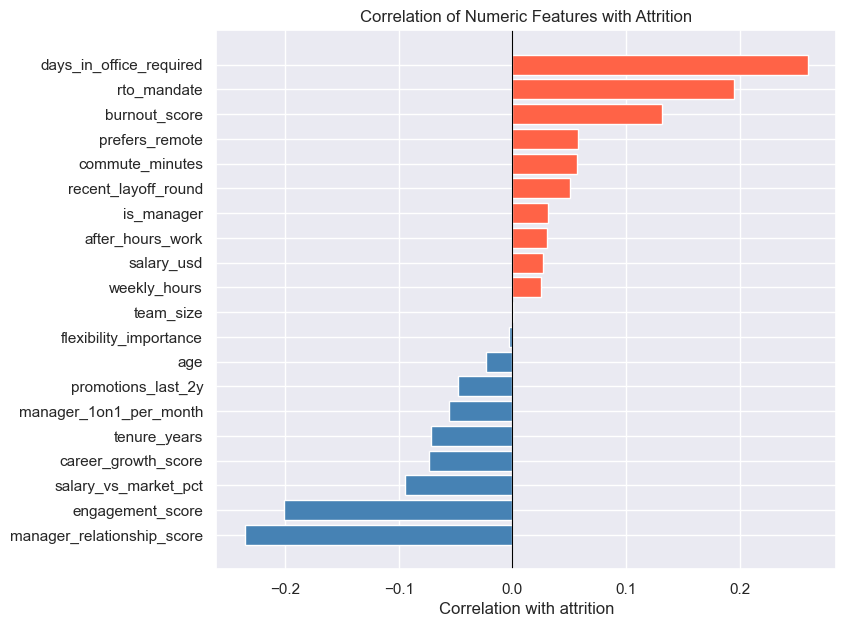

In [41]:
num_cols = df.select_dtypes(include='number').columns.drop(['attrition_pct'])
corr_target = df[num_cols].corr()['attrition'].drop('attrition').sort_values()

colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target.values]
plt.figure(figsize=(8, 7))
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with attrition')
plt.title('Correlation of Numeric Features with Attrition')
plt.savefig("figures/13_corr_with_attrition.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `select_dtypes(include='number')` เลือกเฉพาะคอลัมน์ตัวเลข (ตัด `attrition_pct` ที่เป็นสำเนาของ target ออก)
- `.corr()['attrition']` หาสหสัมพันธ์ Pearson ของทุกตัวแปรกับ attrition แล้วเรียงค่า
- สีแดง = สัมพันธ์ทางบวก (เพิ่มความเสี่ยง), สีน้ำเงิน = ทางลบ (ลดความเสี่ยง)

**Insight**

ปัจจัยเพิ่มความเสี่ยง (บวก): `days_in_office_required` **+0.26**, `rto_mandate` **+0.19**, `burnout_score` **+0.13**
ปัจจัยลดความเสี่ยง (ลบ): `manager_relationship_score` **−0.24**, `engagement_score` **−0.20**, `salary_vs_market_pct` **−0.10**, `career_growth_score` −0.07, `tenure_years` −0.07
- ตัวแปรที่แทบไม่เกี่ยว: `flexibility_importance` (−0.003), `team_size` (0.001), `age`, `salary_usd` (ค่าเงินเดือนสัมบูรณ์ ไม่สำคัญเท่าเงินเดือนเทียบตลาด)
- ค่าสหสัมพันธ์สูงสุดเพียง ~0.26 เพราะ Pearson วัดเฉพาะความสัมพันธ์เชิงเส้นกับ target ที่เป็น 0/1 ค่าจึงดูต่ำแม้ผลต่อกลุ่มจะมาก (เช่นกราฟที่ 7 และ 8)

---

### กราฟที่ 14: Correlation Heatmap (ความสัมพันธ์ระหว่างตัวแปร)

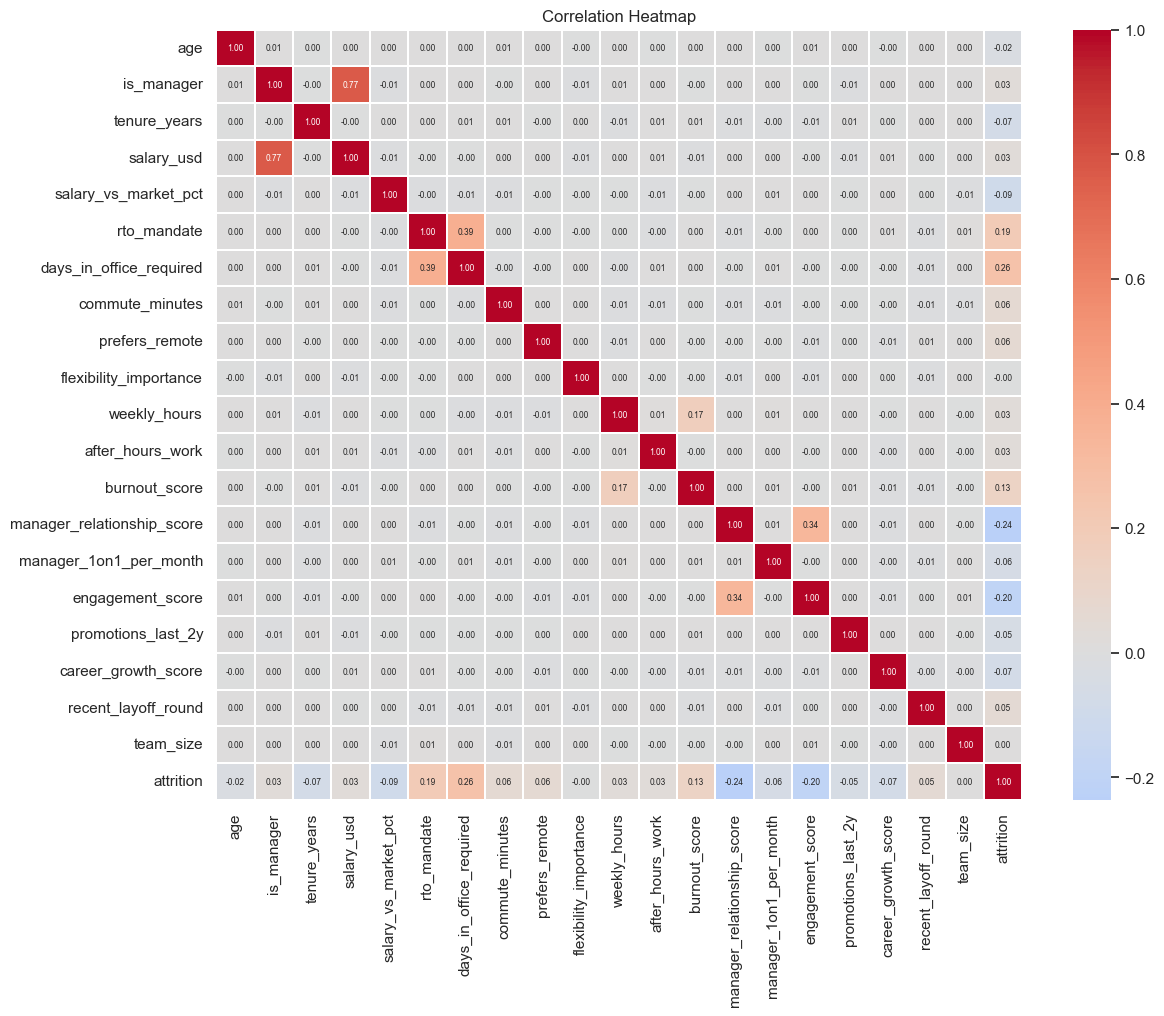

In [42]:
corr = df[num_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 6}, linewidths=0.3)
plt.title('Correlation Heatmap')
plt.savefig("figures/14_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**อธิบายโค้ด**
- `df.corr()` ได้เมทริกซ์สหสัมพันธ์ทุกคู่ตัวแปร
- `sns.heatmap(..., annot=True, cmap='coolwarm', center=0)` แสดงเป็นสี: แดง=บวก, น้ำเงิน=ลบ, ขาว=ใกล้ 0 พร้อมตัวเลขในช่อง
- ใช้ heatmap เพราะต้องดูความสัมพันธ์ "หลายคู่พร้อมกัน" และหา multicollinearity

**Insight**
- คู่ที่สัมพันธ์สูงสุด: `is_manager` – `salary_usd` (**0.77**) ถ้าทำโมเดลควรเลือกใช้ตัวใดตัวหนึ่งหรือระวัง multicollinearity
- `days_in_office_required` – `rto_mandate` (0.39) สัมพันธ์กันปานกลาง เป็นคนละตัวแปรแต่เล่าเรื่องเดียวกัน
- `engagement_score` – `manager_relationship_score` (0.34) ผู้จัดการที่ดีดัน engagement ขึ้น
- `burnout_score` และ `engagement_score` แทบไม่สัมพันธ์กัน (−0.003) สองตัวนี้บอกความเสี่ยงคนละมิติ ใช้เสริมกันได้
- ตัวแปรส่วนใหญ่ไม่สัมพันธ์กันเอง ซึ่งเป็นผลดีต่อการสร้างโมเดลในขั้นถัดไป

---

## 4. ตารางสรุปปัจจัยที่เกี่ยวข้องกับ Attrition

| ลำดับ | ปัจจัย | ผลที่พบ | ความแรง |
|---|---|---|---|
| 1 | จำนวนวันเข้าออฟฟิศ / RTO / onsite | 0 วัน 5.5% → 5 วัน 34.8%; onsite+RTO 42.8% | สูงมาก |
| 2 | ความสัมพันธ์กับผู้จัดการ | คะแนน 1 = 32.3% → คะแนน 5 = 6.9% | สูงมาก |
| 3 | Engagement | ≤40 = 35.4% → >85 = 7.7% | สูง |
| 4 | Burnout | ≤3 = 11.5% → >7 = 27.0% | ปานกลาง–สูง |
| 5 | เงินเดือนเทียบตลาด | ต่ำกว่า 20% = 28.1% → สูงกว่า 20% = 11.7% | ปานกลาง–สูง |
| 6 | โอกาสเติบโต / การเลื่อนตำแหน่ง / 1-on-1 | 22.7% → 14.5% (growth); 0 โปรโมต 19.6% → 2 โปรโมต 14.1% | ปานกลาง |
| 7 | อายุงาน | ≤1 ปี 21.4% → >10 ปี 9.9% | ปานกลาง |
| 8 | Layoff รอบล่าสุด | อยู่ในทีมที่โดน layoff 21.7% vs ไม่ 17.1% | เล็ก |
| 9 | Generation / Job level / Gender / AI | ต่างกัน 2–8 จุด | เล็ก |
| 10 | แผนก / ขนาดทีม / ความสำคัญของ flexibility / เงินเดือนสัมบูรณ์ | แทบไม่ต่าง | ไม่มีนัยสำคัญ |

---

## 5. Proposal: EDA + ปัจจัยที่เกี่ยวข้องกับ Attrition

### 5.1 ที่มาและวัตถุประสงค์
องค์กรมีอัตราการลาออก **18.1%** (8,164 จาก 45,000 คน) จึงต้องการเข้าใจว่า "ใคร" และ "เพราะอะไร" เพื่อวางแผนรักษาพนักงานได้ตรงจุด ส่วนนี้ใช้ EDA หาปัจจัยและกลุ่มเสี่ยง ก่อนต่อยอดเป็นโมเดลทำนาย

### 5.2 ข้อมูลและคุณภาพข้อมูล
- 45,000 แถว, 29 คอลัมน์ ประกอบด้วยข้อมูลประชากร, งาน/ค่าตอบแทน, นโยบาย RTO, ผู้จัดการ, ความผูกพัน/Burnout, การเติบโต และผลลัพธ์ (`attrition`, `attrition_reason`)
- ไม่มี Missing Value ไม่มีข้อมูลซ้ำ
- ข้อควรระวัง: `attrition_reason` เป็น leakage, กลุ่มเล็ก (Boomer 103 คน, เพศ Other 884 คน) สรุปไม่ได้แน่นอน, `tenure_years` มี outlier สูง, มีพนักงาน remote ที่ถูกระบุ RTO (ต้องยืนยันนิยาม)

### 5.3 ข้อค้นพบหลัก
1. **นโยบาย RTO และการเข้าออฟฟิศคือปัจจัยใหญ่ที่สุด** onsite ลาออก 32.8% เทียบกับ remote 11.2% และ 5 กลุ่มลาออกสูงสุดเป็น onsite ทั้งหมด (Engineering onsite 34.8% สูงสุด) ผลกระทบเพิ่มชัดเมื่อต้องเข้าตั้งแต่ 3 วันขึ้นไป
2. **ผู้จัดการคือปัจจัยที่ควบคุมได้มากที่สุด** คะแนนความสัมพันธ์ต่ำสุดลาออก 32.3% ต่างจากสูงสุด (6.9%) เกือบ 5 เท่า และ Poor management เป็นเหตุผลลาออกอันดับ 1 (26.5%)
3. **Engagement และ Burnout เป็นสัญญาณเตือนล่วงหน้า** Engagement ≤40 ลาออก 35.4%, Burnout >7 ลาออก 27.0%
4. **ค่าตอบแทนเทียบตลาดสำคัญกว่าเงินเดือนสัมบูรณ์** ต่ำกว่าตลาดเกิน 20% ลาออก 28.1%
5. **ปัจจัยรองลงมา:** โอกาสเติบโต, การเลื่อนตำแหน่ง, 1-on-1, อายุงานน้อย, Gen Z, ระดับ Lead ขึ้นไป, ไม่ใช้ AI
6. **แผนก ขนาดทีม และความสำคัญของ flexibility ไม่ใช่ตัวแยกความเสี่ยง** เมื่อไม่ควบคุมปัจจัยอื่น

### 5.4 กลุ่มเสี่ยงและกลุ่มที่รักษาไว้ได้ดี
- **เสี่ยงสูงสุด 5 อันดับ:** Engineering / Customer Support / Marketing / Product / HR ที่ทำงาน onsite (32.6%–34.8%)
- **อยู่ต่อมากสุด 5 อันดับ:** Finance / Customer Support / Engineering / Operations / Marketing ที่ทำงาน remote (88.5%–90.8%)

### 5.5 ข้อเสนอแนะเชิงปฏิบัติ
1. ทบทวนนโยบาย RTO โดยเฉพาะการบังคับ 4–5 วัน/สัปดาห์ ลองเพดาน 2–3 วัน และเริ่มจากกลุ่ม Engineering/Customer Support onsite
2. ตั้งโปรแกรมพัฒนาผู้จัดการ และกำหนด 1-on-1 อย่างน้อย 2 ครั้ง/เดือน ติดตามคะแนนความสัมพันธ์รายทีม
3. ตั้ง Early-warning dashboard: Engagement ≤40, Burnout >7, เงินเดือนต่ำกว่าตลาดเกิน 10–20%, อายุงาน ≤1 ปี
4. ปรับเงินเดือนกลุ่มที่ต่ำกว่าตลาดมาก และสร้างเส้นทางการเติบโต/โปรโมตให้ชัด
5. ดูแลพนักงานใหม่ใน 3 ปีแรก (onboarding, mentor)

### 5.6 ข้อจำกัด
- ความสัมพันธ์ที่พบเป็น **correlation ไม่ใช่ causation** (เช่น คนใช้ AI มากลาออกน้อย อาจสะท้อนความผูกพัน)
- เป็นข้อมูลภาพตัดขวาง (cross-sectional) ไม่เห็นการเปลี่ยนแปลงตามเวลา
- ยังไม่ได้ทดสอบนัยสำคัญทางสถิติ (Chi-square / t-test) และยังไม่ได้ควบคุมปัจจัยร่วม (confounder) เช่น RTO กับรูปแบบการทำงาน

### 5.7 ขั้นตอนถัดไป
1. ทดสอบสถิติ (Chi-square สำหรับตัวแปรหมวดหมู่, t-test/Mann-Whitney สำหรับตัวแปรต่อเนื่อง)
2. สร้างโมเดลทำนาย (Logistic Regression เป็น baseline, Random Forest / Gradient Boosting) โดย **ตัด `attrition_reason` ออก**, จัดการ imbalance (class weight) และดู Feature Importance
3. ตรวจสอบ interaction เช่น RTO × รูปแบบการทำงาน, ผู้จัดการ × Engagement
4. คำนวณต้นทุนการลาออกเพื่อจัดลำดับความคุ้มค่าของมาตรการ